# Logistic Regression with the Titanic Survival Dataset
**Date:** March, 2026  
**Author:** Dario Piga  

In this notebook, we will implement a logistic regression model using `pytorch` to predict survival on the Titanic. Our goal is to understand how various factors such as passenger class, gender, age, and fare contribute to the likelihood of survival. By applying logistic regression, we will model these relationships to predict binary outcomes, specifically, whether a passenger survived or not.

## The Titanic Survival Dataset

The Titanic dataset is a historical dataset that contains data on the passengers aboard the RMS Titanic, which famously sank on its maiden voyage in 1912. This dataset includes the following features:

- `survived`: Survival (0 = No, 1 = Yes)
- `pclass`: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
- `sex`: Gender (male or female)
- `age`: Age in years
- `fare`: Passenger fare
- and others not used in this exercise
  
We will explore the data, perform necessary preprocessing steps, and build a logistic regression model to predict whether a passenger survived based on their features. We will also evaluate our model's performance using various metrics to understand its effectiveness.


In [1]:
import seaborn as sns
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch.nn as nn

In [2]:
# Load dataset
df = sns.load_dataset('titanic')

# Select specific columns
features = ['pclass', 'sex', 'age', 'fare']
df = df[features + ['survived']]

# Drop rows with any NaN values
df.dropna(inplace=True)

# Print the DataFrame
print(df)

     pclass     sex   age     fare  survived
0         3    male  22.0   7.2500         0
1         1  female  38.0  71.2833         1
2         3  female  26.0   7.9250         1
3         1  female  35.0  53.1000         1
4         3    male  35.0   8.0500         0
..      ...     ...   ...      ...       ...
885       3  female  39.0  29.1250         0
886       2    male  27.0  13.0000         0
887       1  female  19.0  30.0000         1
889       1    male  26.0  30.0000         1
890       3    male  32.0   7.7500         0

[714 rows x 5 columns]


In [3]:
# Convert gender into binary variable (0 or 1)
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
# Selecting specific features
X = df[features]
y = df['survived']


p(survived=1 | geneder=male): 0.2052980132450331
p(survived=1 | geneder=female): 0.7547892720306514


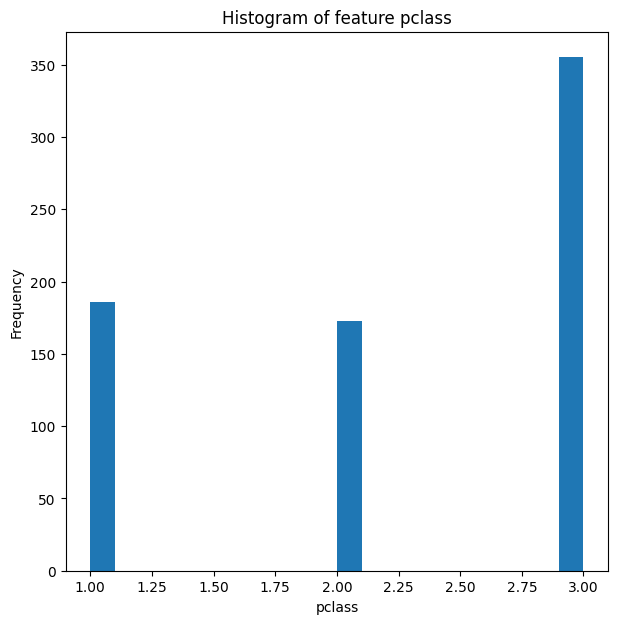

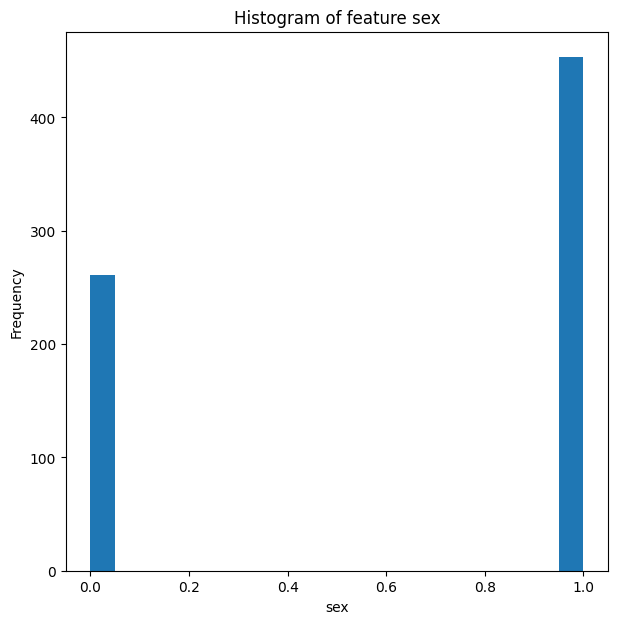

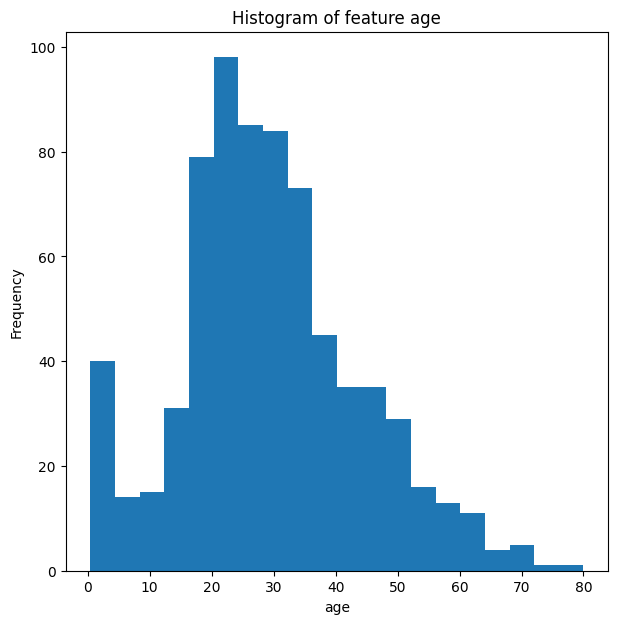

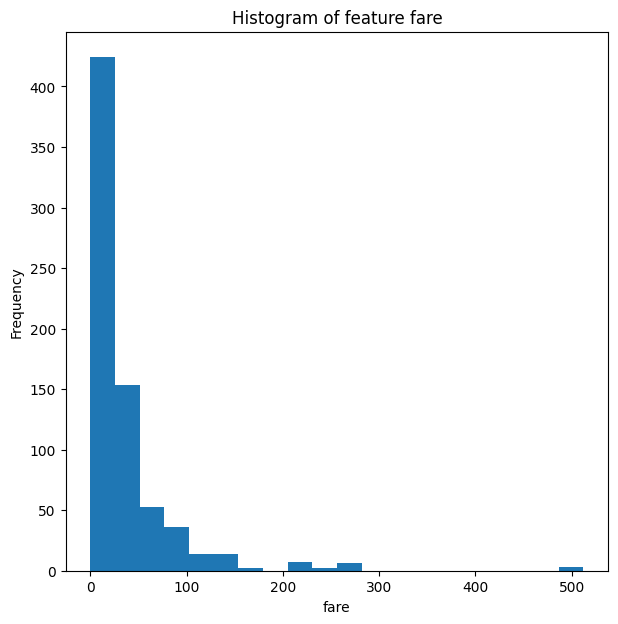

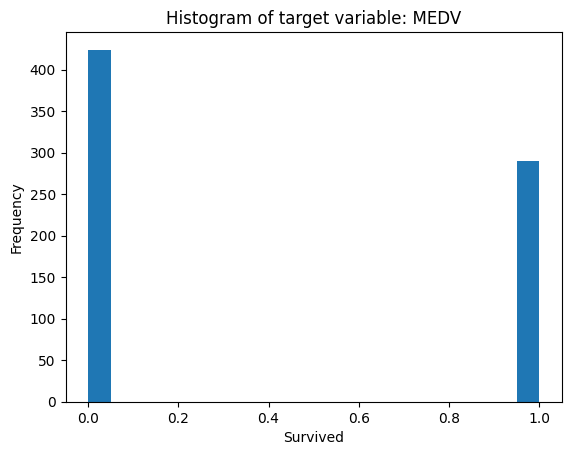

In [4]:
# Plot your data (solution)

for f in features:
    plt.figure(figsize=(7,7))
    plt.hist(df[f], bins = 20)
    plt.title(f'Histogram of feature {f}')
    plt.xlabel(f)
    plt.ylabel('Frequency')


plt.figure()
plt.hist(y, bins = 20)
plt.title(f"Histogram of target variable: MEDV")
plt.xlabel('Survived')
plt.ylabel('Frequency')


# compute conditional empirical distributions (p(y=1|gender = male))
index_men = df['sex'] == 1
number_of_men = sum(index_men)
number_of_survided_men = sum(df.loc[index_men]['survived']==1)
ratio_survided_men = number_of_survided_men/number_of_men
print(f"p(survived=1 | geneder=male): {ratio_survided_men}")

# compute conditional empirical distributions (p(y=1|gender = female))
index_female = df['sex'] == 0
number_of_female = sum(index_female)
number_of_survided_female = sum(df.loc[index_female]['survived']==1)
ratio_survided_female = number_of_survided_female/number_of_female
print(f"p(survived=1 | geneder=female): {ratio_survided_female}")

In [5]:
# Splitting the dataset into training and testing sets and normalize (solution)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features and output to have zero mean and unitary std

# Normalize training and test dataset. Note that training and test datasets are normalized using the same mean and std 
X_mean = X_train.mean(axis = 0)
X_std = X_train.std(axis = 0)
X_train = (X_train - X_mean)/X_std 
X_test = (X_test - X_mean)/X_std


# sanity check:
print(f"Training features: \n Mean:\n {X_train.mean(axis = 0)} \n Std:\n {X_train.std(axis = 0)}\n")
print(f"Training target: \n Mean:\n {y_train.mean():.2f} \n Std:\n {y_train.std():.2f}")


Training features: 
 Mean:
 pclass    8.088490e-17
sex       2.799862e-17
age       2.488766e-16
fare      5.288628e-17
dtype: float64 
 Std:
 pclass    1.0
sex       1.0
age       1.0
fare      1.0
dtype: float64

Training target: 
 Mean:
 0.41 
 Std:
 0.49


In [6]:
# Convert datasets to tensors

X_train_tensor = torch.tensor(X_train.values, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32)

X_test_tensor = torch.tensor(X_test.values, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32)

In [7]:
# Define model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        # Linear layer
        self.linear = nn.Linear(input_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Applying the linear layer and then the sigmoid function
        outputs = self.sigmoid(self.linear(x))
        return outputs

model = LogisticRegressionModel(input_dim = X.shape[1])

print(f"Model structure: {model}")

for name, params in model.named_parameters():
    print(f"parameter name: {name}. Value {params.data}")

# check what model provides:
y_hat = model(X_train_tensor)
y_hat.shape

Model structure: LogisticRegressionModel(
  (linear): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
parameter name: linear.weight. Value tensor([[-0.0635,  0.2061, -0.4849, -0.0646]])
parameter name: linear.bias. Value tensor([0.0366])


torch.Size([571, 1])

In [8]:
# Define the loss function for binary classification
criterion = nn.BCELoss() # Binary cross entropy

# define optimizer
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)


In [9]:
# training loop (TBD)
max_iter = 5000
for it in range(max_iter):

    optimizer.zero_grad()
    p = model(X_train_tensor)
    #print(p.shape, y_train_tensor.reshape(-1,1).shape) 
    loss = criterion(p, y_train_tensor.reshape(-1,1))
    loss.backward()
    optimizer.step()

    if it%10 == 0:

        p_hat = model(X_train_tensor)
        y_hat =  (p_hat > 0.5).float()
        accuracy = (y_hat == y_train_tensor.reshape(-1,1)).float().mean()
            
        
        print(f"Iteration: {it}. Loss: {loss:.3f}. Accuracy: {accuracy}")
        

Iteration: 0. Loss: 0.751. Accuracy: 0.41681259870529175
Iteration: 10. Loss: 0.734. Accuracy: 0.44133099913597107
Iteration: 20. Loss: 0.717. Accuracy: 0.46935200691223145
Iteration: 30. Loss: 0.702. Accuracy: 0.4956217110157013
Iteration: 40. Loss: 0.688. Accuracy: 0.5218914151191711
Iteration: 50. Loss: 0.675. Accuracy: 0.5376532673835754
Iteration: 60. Loss: 0.663. Accuracy: 0.567425549030304
Iteration: 70. Loss: 0.651. Accuracy: 0.6042031645774841
Iteration: 80. Loss: 0.640. Accuracy: 0.6427320241928101
Iteration: 90. Loss: 0.630. Accuracy: 0.6742556691169739
Iteration: 100. Loss: 0.621. Accuracy: 0.7005254030227661
Iteration: 110. Loss: 0.612. Accuracy: 0.7197898626327515
Iteration: 120. Loss: 0.604. Accuracy: 0.7285463809967041
Iteration: 130. Loss: 0.596. Accuracy: 0.7460595369338989
Iteration: 140. Loss: 0.589. Accuracy: 0.7530648112297058
Iteration: 150. Loss: 0.582. Accuracy: 0.7688266038894653
Iteration: 160. Loss: 0.576. Accuracy: 0.7863397598266602
Iteration: 170. Loss: 0

Iteration: 1550. Loss: 0.444. Accuracy: 0.7985989451408386
Iteration: 1560. Loss: 0.444. Accuracy: 0.7985989451408386
Iteration: 1570. Loss: 0.444. Accuracy: 0.7985989451408386
Iteration: 1580. Loss: 0.444. Accuracy: 0.7985989451408386
Iteration: 1590. Loss: 0.444. Accuracy: 0.7985989451408386
Iteration: 1600. Loss: 0.444. Accuracy: 0.7985989451408386
Iteration: 1610. Loss: 0.444. Accuracy: 0.7985989451408386
Iteration: 1620. Loss: 0.443. Accuracy: 0.7985989451408386
Iteration: 1630. Loss: 0.443. Accuracy: 0.7985989451408386
Iteration: 1640. Loss: 0.443. Accuracy: 0.7985989451408386
Iteration: 1650. Loss: 0.443. Accuracy: 0.7985989451408386
Iteration: 1660. Loss: 0.443. Accuracy: 0.7985989451408386
Iteration: 1670. Loss: 0.443. Accuracy: 0.7985989451408386
Iteration: 1680. Loss: 0.443. Accuracy: 0.7985989451408386
Iteration: 1690. Loss: 0.443. Accuracy: 0.7985989451408386
Iteration: 1700. Loss: 0.443. Accuracy: 0.7985989451408386
Iteration: 1710. Loss: 0.443. Accuracy: 0.79859894514083

Iteration: 3410. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3420. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3430. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3440. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3450. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3460. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3470. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3480. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3490. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3500. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3510. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3520. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3530. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3540. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3550. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3560. Loss: 0.439. Accuracy: 0.8091068267822266
Iteration: 3570. Loss: 0.439. Accuracy: 0.80910682678222

Iteration: 4960. Loss: 0.439. Accuracy: 0.8143607974052429
Iteration: 4970. Loss: 0.439. Accuracy: 0.8143607974052429
Iteration: 4980. Loss: 0.439. Accuracy: 0.8143607974052429
Iteration: 4990. Loss: 0.439. Accuracy: 0.8143607974052429


In [10]:
for name, p in model.named_parameters():
    print(f"Parameter {name}. Value: {p}")

Parameter linear.weight. Value: Parameter containing:
tensor([[-1.0358, -1.2756, -0.6113,  0.0287]], requires_grad=True)
Parameter linear.bias. Value: Parameter containing:
tensor([-0.4930], requires_grad=True)


In [11]:
# assess performance (solution)

import matplotlib.pyplot as plt

def assess_results(model, X, y, data_type):
    with torch.no_grad():
        p_hat = model(X).squeeze()  # Get the predicted probabilities
        y_hat = (p_hat > 0.5).float()  # Convert probabilities to 0 or 1 based on threshold

        # Prediction and plotting
        plt.figure(figsize=(5, 5))
        plt.scatter(p_hat.numpy(), y.numpy(), alpha=0.5)  # Use scatter plot for clarity
        plt.title(f'Predicted vs. True - {data_type} Data')
        plt.xlabel('Estimated Probability ($\hat{p}$)')
        plt.ylabel('True Output')
        plt.grid(True)
        plt.show()

        # Compute accuracy
        accuracy = torch.mean((y_hat == y).float()).item()  # Convert boolean to float and calculate mean

        # Compute confusion matrix
        TP = torch.sum((y_hat == 1) & (y == 1)).item()  # True Positive
        TN = torch.sum((y_hat == 0) & (y == 0)).item()  # True Negative
        FP = torch.sum((y_hat == 1) & (y == 0)).item()  # False Positive
        FN = torch.sum((y_hat == 0) & (y == 1)).item()  # False Negative

        # Print confusion matrix results
        print(f"Accuracy: {accuracy*100:.3f} % ")
        print(f"Confusion Matrix for {data_type} Data:")
        print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
        


Training results


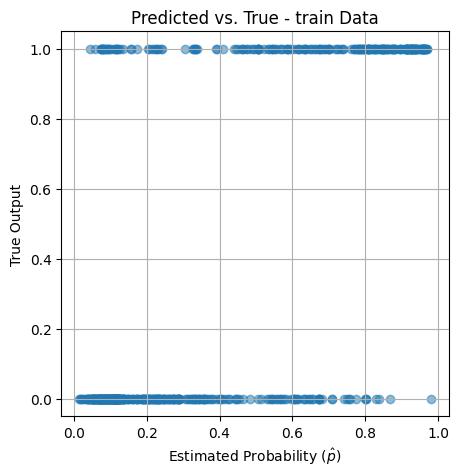

Accuracy: 81.436 % 
Confusion Matrix for train Data:
TP: 176, TN: 289, FP: 48, FN: 58
Test results


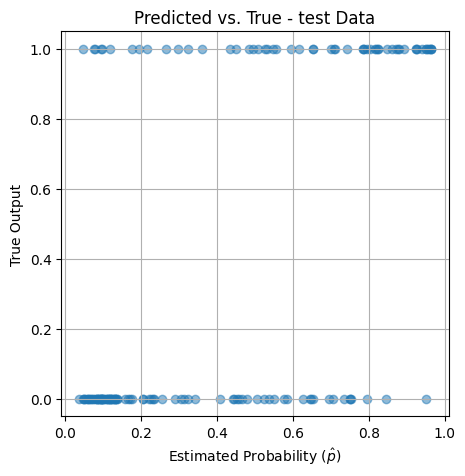

Accuracy: 74.825 % 
Confusion Matrix for test Data:
TP: 39, TN: 68, FP: 19, FN: 17


In [12]:
# Assess results in training
print('Training results')

assess_results(model, X_train_tensor, y_train_tensor, data_type = 'train')
#print(f"rmse = {rmse}. R2 = {R2:.3f}")


# Assess results in test
print('Test results')

assess_results(model, X_test_tensor, y_test_tensor, data_type = 'test')
#print(f"rmse = {rmse}. R2 = {R2:.3f}")
